import


In [2]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

from transformers import (
    VisionEncoderDecoderModel,
    AutoTokenizer,
    ViTImageProcessor
)

c:\Users\osamg\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load Saved Model

In [3]:

import os
from transformers import (
    VisionEncoderDecoderModel,
    AutoTokenizer,
    ViTImageProcessor
)

model_path = "./vit_gpt2_flickr30k"

print("Exists:", os.path.exists(model_path))

model = VisionEncoderDecoderModel.from_pretrained(
    model_path,
    local_files_only=True
)

tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    local_files_only=True
)

feature_extractor = ViTImageProcessor.from_pretrained(
    model_path,
    local_files_only=True
)

print("Model Loaded Successfully!")

Exists: True


Loading weights: 100%|██████████| 444/444 [00:00<00:00, 10392.66it/s]


Model Loaded Successfully!


device

In [4]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

print(device)

cuda


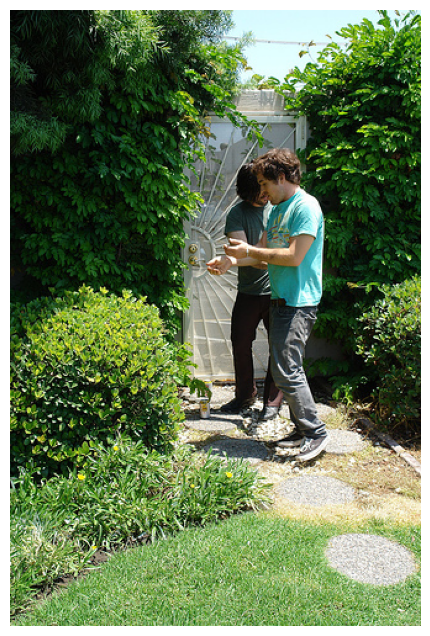

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Generated Caption:
a man in a blue shirt and a woman in a green shirt are standing in front of a fence 


In [5]:
test_image = "flickr30k_images/flickr30k_images/1000092795.jpg"

image = Image.open(test_image).convert("RGB")

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

pixel_values = feature_extractor(
    images=image,
    return_tensors="pt"
).pixel_values.to(device)

generated_ids = model.generate(
    pixel_values,
    max_length=24,
    num_beams=7,
    no_repeat_ngram_size=3,
    early_stopping=True
)

generated_caption = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True
)

print("Generated Caption:")
print(generated_caption)

Image: 2757779501.jpg


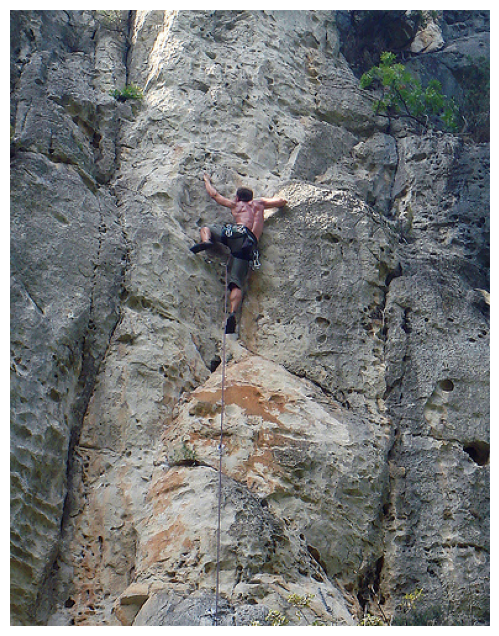


Generated Caption:
a man on a rock climbing up the side of a mountain 

Real Caption:
 A shirtless person with jeans is climbing a rocky mountainside .


In [6]:
import os
import random
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move model to GPU
model.to(device)

# Load CSV
df = pd.read_csv("flickr30k_images/results.csv", sep="|")

# Clean columns
df.columns = df.columns.str.strip()

# Clean image names
df["image_name"] = df["image_name"].str.strip()

# Images folder
image_folder = "flickr30k_images/flickr30k_images"

# Random image
all_images = os.listdir(image_folder)

random_image = random.choice(all_images)

# Image path
test_image = os.path.join(
    image_folder,
    random_image
)

print("Image:", random_image)

# Open image
image = Image.open(test_image).convert("RGB")

# Display image
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

# Preprocessing
pixel_values = feature_extractor(
    images=image,
    return_tensors="pt"
).pixel_values.to(device)

# Generate caption
generated_ids = model.generate(

    pixel_values,

    max_length=24,

    min_length=8,

    num_beams=7,

    early_stopping=True,

    no_repeat_ngram_size=3,

    length_penalty=1.0
)

# Decode generated caption
generated_caption = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True
)

# Get first real caption
real_caption = df[
    df["image_name"] == random_image
]["comment"].iloc[0]

# Output
print("\nGenerated Caption:")
print(generated_caption)

print("\nReal Caption:")
print(real_caption)

evalution

In [7]:
import os
import random
import torch
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from evaluate import load

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

# Load BLEU metric
bleu = load("bleu")

# Load dataset
df = pd.read_csv(
    "flickr30k_images/results.csv",
    sep="|"
)

# Clean columns
df.columns = df.columns.str.strip()

df["image_name"] = df["image_name"].str.strip()

# Sample random validation examples
samples = df.sample(20, random_state=42)

predictions = []
references = []

# Images folder
image_folder = "flickr30k_images/flickr30k_images"

for _, row in samples.iterrows():

    image_path = os.path.join(
        image_folder,
        row["image_name"]
    )

    image = Image.open(image_path).convert("RGB")

    pixel_values = feature_extractor(
        images=image,
        return_tensors="pt"
    ).pixel_values.to(device)

    generated_ids = model.generate(

        pixel_values,

        max_length=24,

        num_beams=7,

        no_repeat_ngram_size=3,

        early_stopping=True
    )

    generated_caption = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    predictions.append(generated_caption)

    references.append([row["comment"]])

# Compute BLEU
results = bleu.compute(
    predictions=predictions,
    references=references
)

print("BLEU Score:", results["bleu"])

BLEU Score: 0.025714164705833573


prediction eva


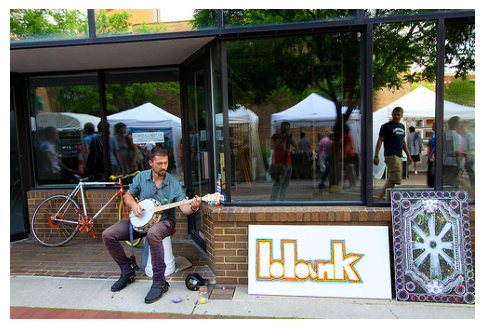

Generated Caption:
a man sitting on a bench next to a woman talking on a cell phone outside a store 

Real Caption:
 A man is sitting on an upturned white bucket playing a banjo .




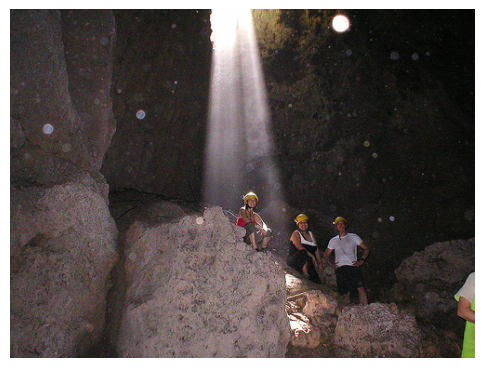

Generated Caption:
a number of people standing on top of a rock wall near a waterfall 

Real Caption:
 Spelunkers pose inside a rock cavern while bathed in sunlight from the surface .




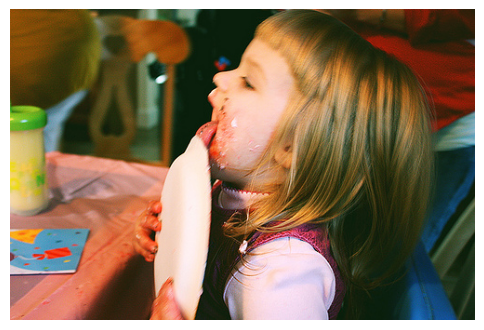

Generated Caption:
a little girl in a pink shirt is eating a piece of cake 

Real Caption:
 A toddler enjoying her birthday cake .




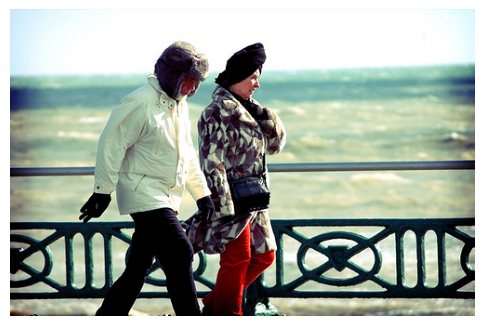

Generated Caption:
a man and a woman are walking down the street with their surfboards in hand 

Real Caption:
 Two people are walking by the ocean .




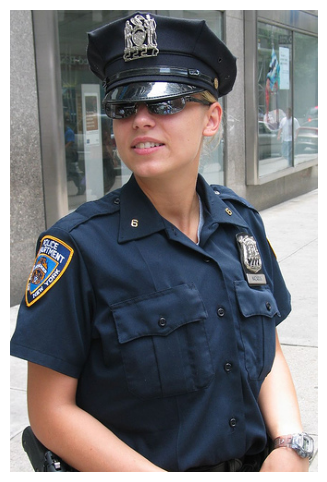

Generated Caption:
a police officer wearing a uniform is standing in front of a building with a flag on it 

Real Caption:
 Young , smiling , blond female police officer from New York standing outside on a sidewalk .




In [8]:
for i in range(5):

    sample = samples.iloc[i]

    image_path = os.path.join(
        image_folder,
        sample["image_name"]
    )

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Generated Caption:")
    print(predictions[i])

    print("\nReal Caption:")
    print(sample["comment"])

    print("\n" + "="*60 + "\n")

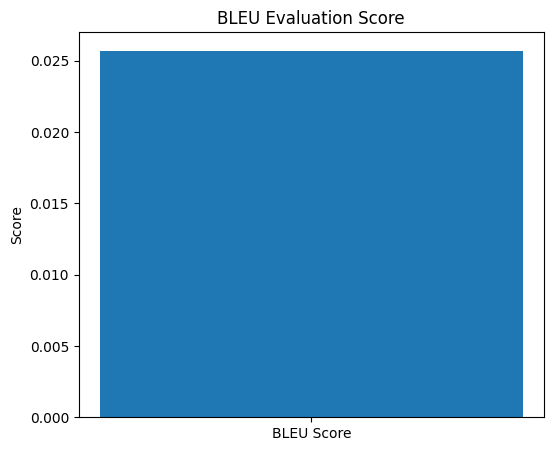

In [9]:
plt.figure(figsize=(6,5))

plt.bar(
    ["BLEU Score"],
    [results["bleu"]]
)

plt.ylabel("Score")

plt.title("BLEU Evaluation Score")

plt.show()